## Feature Selection and Feature Correlations

This notebook builds upon the previous one and removes all features with an importance score of less than 0.01.  
This threshold was guided by the results produced from the previous notebook.  
Following the feature selection, the focus switched to feature engineering,  
where correlations between the remaining features are investigated to figure out how they can be combined to produce new features.

In [1]:
library("tidymodels")
library("tidyverse")
library("stringr")
library("xgboost")

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.5     ✔ recipes      1.0.8
✔ dials        1.2.0     ✔ rsample      1.2.0
✔ dplyr        1.1.3     ✔ tibble       3.2.1
✔ ggplot2      3.4.4     ✔ tidyr        1.3.0
✔ infer        1.0.5     ✔ tune         1.1.2
✔ modeldata    1.2.0     ✔ workflows    1.1.3
✔ parsnip      1.1.1     ✔ workflowsets 1.0.1
✔ purrr        1.0.2     ✔ yardstick    1.2.0

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()
• Use tidymodels_prefer() to resolve common conflicts.

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.4
✔ lubridate 1.9.3     ✔ stringr   1.5.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::

In [2]:
#Read in the dataset
bike_sharing_df <- read_csv("../data_preprocessed/processed_seoul_bike_sharing_normalized.csv")
spec(bike_sharing_df)

Rows: 8465 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): DATE, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (40): RENTED_BIKE_COUNT, HOUR, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cols(
  DATE = col_character(),
  RENTED_BIKE_COUNT = col_double(),
  HOUR = col_double(),
  TEMPERATURE = col_double(),
  HUMIDITY = col_double(),
  WIND_SPEED = col_double(),
  VISIBILITY = col_double(),
  DEW_POINT_TEMPERATURE = col_double(),
  SOLAR_RADIATION = col_double(),
  RAINFALL = col_double(),
  SNOWFALL = col_double(),
  SEASONS = col_character(),
  HOLIDAY = col_character(),
  FUNCTIONING_DAY = col_character(),
  SEASONS_AUTUMN = col_double(),
  SEASONS_SPRING = col_double(),
  SEASONS_SUMMER = col_double(),
  SEASONS_WINTER = col_double(),
  HOLIDAY_HOLIDAY = col_double(),
  HOLIDAY_NO_HOLIDAY = col_double(),
  HOUR_0 = col_double(),
  HOUR_1 = col_double(),
  HOUR_2 = col_double(),
  HOUR_3 = col_double(),
  HOUR_4 = col_double(),
  HOUR_5 = col_double(),
  HOUR_6 = col_double(),
  HOUR_7 = col_double(),
  HOUR_8 = col_double(),
  HOUR_9 = col_double(),
  HOUR_10 = col_double(),
  HOUR_11 = col_double(),
  HOUR_12 = col_double(),
  HOUR_13 = col_double(),
  HOUR_14 = co

We won't be using the `DATE` column, because 'as is', it basically acts like an data entry index.  
(However, given more time, we could use the `DATE` colum to create a 'day of week' or 'isWeekend' column, which we might expect has an affect on preferred bike rental times.)   
We also do not need the `FUNCTIONAL DAY` column because it only has one distinct value remaining (`YES`) after missing value processing.  
We will also be removing everything with Gain value below 0.01.

In [3]:
bike_sharing_df <- bike_sharing_df %>% select(-DATE, -FUNCTIONING_DAY, -HOLIDAY_HOLIDAY, -SEASONS_SPRING, -HOUR_7, -HOUR_10,
                                              -SEASONS_SUMMER, -HOUR_19, -HOUR_4, -SNOWFALL, -HOUR_5, -HOUR_11, -HOUR_21, -SEASONS_WINTER,
                                              -HOUR_9, -HOUR_16, -HOUR_15, -HOUR_17, -HOUR_6, -HOUR_14, -HOUR_20, -HOUR_12, -HOUR_22,
                                              -HOUR_13, -HOUR_2, -HOUR_1, -HOUR_3)

head(bike_sharing_df)

RENTED_BIKE_COUNT,HOUR,TEMPERATURE,HUMIDITY,WIND_SPEED,VISIBILITY,DEW_POINT_TEMPERATURE,SOLAR_RADIATION,RAINFALL,SEASONS,HOLIDAY,SEASONS_AUTUMN,HOLIDAY_NO_HOLIDAY,HOUR_0,HOUR_8,HOUR_18,HOUR_23
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.07090602,0,0.2202797,0.3775510,0.2972973,1,0.2249135,0,0,Winter,No Holiday,0,1,1,0,0,0
0.05683737,1,0.2150350,0.3877551,0.1081081,1,0.2249135,0,0,Winter,No Holiday,0,1,0,0,0,0
0.04811480,2,0.2062937,0.3979592,0.1351351,1,0.2231834,0,0,Winter,No Holiday,0,1,0,0,0,0
0.02954418,3,0.2027972,0.4081633,0.1216216,1,0.2249135,0,0,Winter,No Holiday,0,1,0,0,0,0
0.02138436,4,0.2062937,0.3673469,0.3108108,1,0.2076125,0,0,Winter,No Holiday,0,1,0,0,0,0
0.02757456,5,0.1993007,0.3775510,0.2027027,1,0.2058824,0,0,Winter,No Holiday,0,1,0,0,0,0


In [4]:
dim(bike_sharing_df)

cat("Rows:", nrow(bike_sharing_df), "\n")
cat("Columns:", ncol(bike_sharing_df), "\n")

[1] 8465   17

Rows: 8465 
Columns: 17 


In [5]:
summary(bike_sharing_df)

 RENTED_BIKE_COUNT      HOUR        TEMPERATURE        HUMIDITY     
 Min.   :0.00000   Min.   : 0.00   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:0.05965   1st Qu.: 6.00   1st Qu.:0.3636   1st Qu.:0.4286  
 Median :0.15194   Median :12.00   Median :0.5472   Median :0.5816  
 Mean   :0.20460   Mean   :11.51   Mean   :0.5345   Mean   :0.5933  
 3rd Qu.:0.30445   3rd Qu.:18.00   3rd Qu.:0.7080   3rd Qu.:0.7551  
 Max.   :1.00000   Max.   :23.00   Max.   :1.0000   Max.   :1.0000  
   WIND_SPEED       VISIBILITY     DEW_POINT_TEMPERATURE SOLAR_RADIATION   
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000        Min.   :0.000000  
 1st Qu.:0.1216   1st Qu.:0.4602   1st Qu.:0.4412        1st Qu.:0.000000  
 Median :0.2027   Median :0.8429   Median :0.6107        Median :0.002841  
 Mean   :0.2332   Mean   :0.7131   Mean   :0.5977        Mean   :0.161326  
 3rd Qu.:0.3108   3rd Qu.:1.0000   3rd Qu.:0.7924        3rd Qu.:0.264205  
 Max.   :1.0000   Max.   :1.0000   Max.   :1.0000        Max.

In [7]:
glimpse(bike_sharing_df)

Rows: 8,465
Columns: 17
$ RENTED_BIKE_COUNT     <dbl> 0.07090602, 0.05683737, 0.04811480, 0.02954418, …
$ HOUR                  <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14…
$ TEMPERATURE           <dbl> 0.2202797, 0.2150350, 0.2062937, 0.2027972, 0.20…
$ HUMIDITY              <dbl> 0.3775510, 0.3877551, 0.3979592, 0.4081633, 0.36…
$ WIND_SPEED            <dbl> 0.29729730, 0.10810811, 0.13513514, 0.12162162, …
$ VISIBILITY            <dbl> 1.0000000, 1.0000000, 1.0000000, 1.0000000, 1.00…
$ DEW_POINT_TEMPERATURE <dbl> 0.2249135, 0.2249135, 0.2231834, 0.2249135, 0.20…
$ SOLAR_RADIATION       <dbl> 0.000000000, 0.000000000, 0.000000000, 0.0000000…
$ RAINFALL              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ SEASONS               <chr> "Winter", "Winter", "Winter", "Winter", "Winter"…
$ HOLIDAY               <chr> "No Holiday", "No Holiday", "No Holiday", "No Ho…
$ SEASONS_AUTUMN        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ HOLIDAY_NO_HOL

In [8]:
sum(is.na(bike_sharing_df))

[1] 0

### Feature Correlations

It is important to gauge how variables interact or are related for future feature engineering.

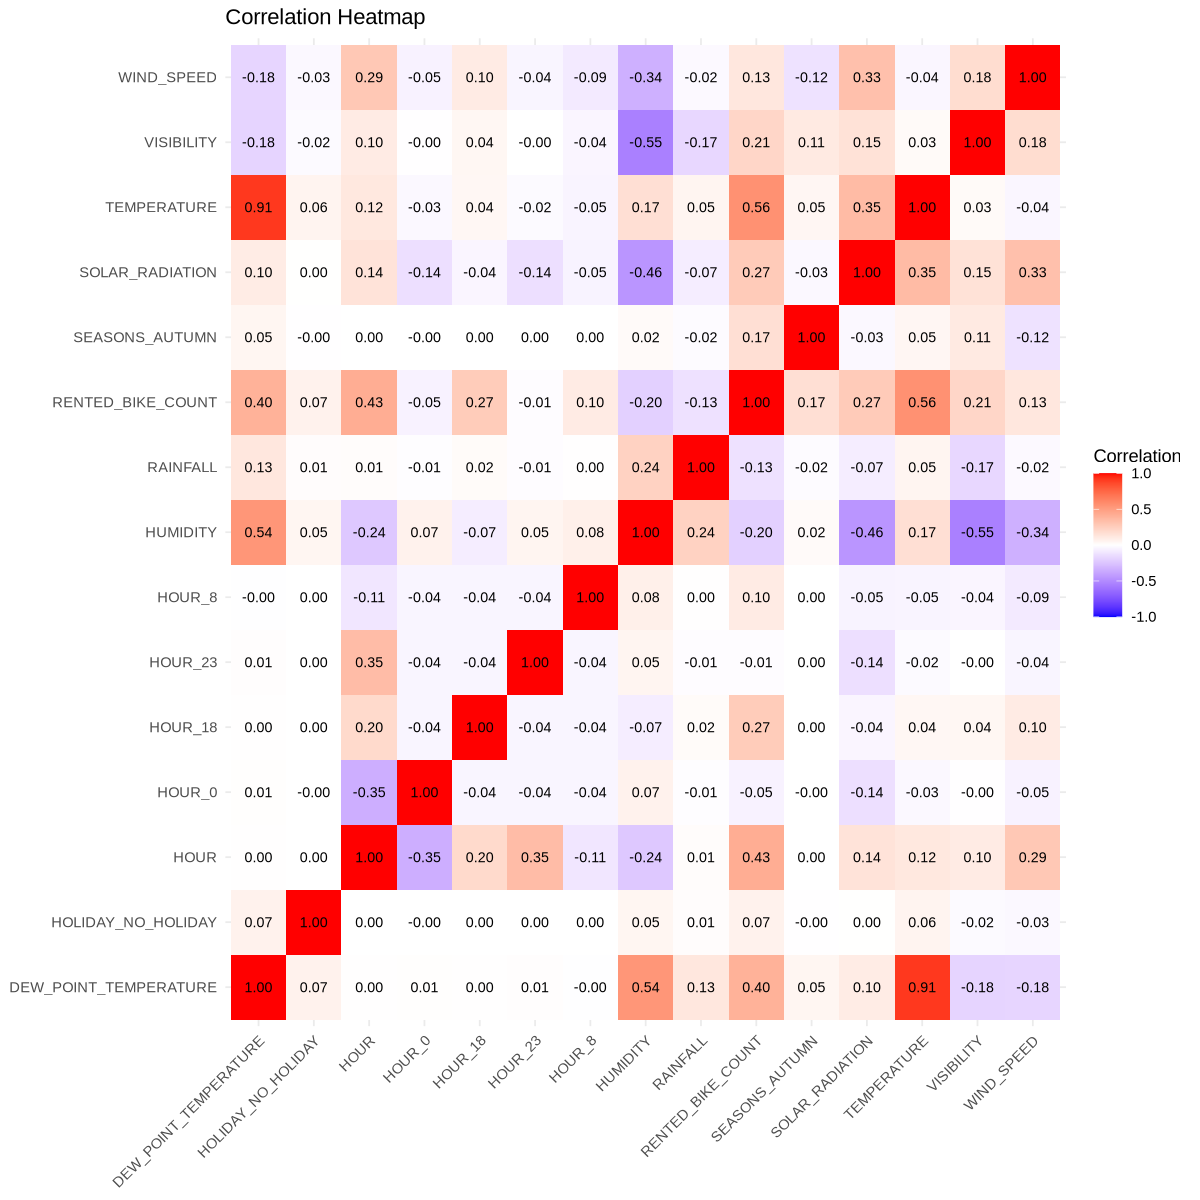

In [17]:
numeric_features <- bike_sharing_df %>%
  select(where(is.numeric))

correlation_matrix <- cor(numeric_features)

options(
  repr.plot.width = 10,
  repr.plot.height = 10
)

correlation_matrix %>%
  as.data.frame() %>%
  rownames_to_column("Feature1") %>%
  pivot_longer(
    cols = -Feature1,
    names_to = "Feature2",
    values_to = "Correlation"
  ) %>%
  ggplot(
    aes(
      x = Feature1,
      y = Feature2,
      fill = Correlation
    )
  ) +
  geom_tile() +
  geom_text(
    aes(label = sprintf("%.2f", Correlation)),
    size = 3
  ) +
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0,
    limits = c(-1, 1)
  ) +
  labs(
    title = "Correlation Heatmap",
    x = NULL,
    y = NULL,
    fill = "Correlation"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )